In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import os
import seaborn as sns

In [2]:
def impute_mY(mY, years, method='linear'):
    """
    Impute missing in mY (shape T×N) by per-column interpolation
    on the year index, then forward/backward fill.
    """
    df = pd.DataFrame(mY, index=years)
    df = df.interpolate(method=method, axis=0) \
           .ffill(axis=0) \
           .bfill(axis=0)
    return df.values

def process_and_plot_yield_map(csv_filepath):
    """
    Loads county yield data, imputes missing values for a specific time range,
    calculates the average yield per county, and plots the result on a map.
    """
    # --- 1. Load and Prepare Data ---
    
    print(f"Loading data from: {csv_filepath}")
    if not os.path.exists(csv_filepath):
        print(f"FATAL ERROR: The file '{csv_filepath}' was not found.")
        return

    try:
        # Load the data, ensuring key columns are read as strings to start.
        df = pd.read_csv(csv_filepath, dtype={'state': str, 'county': str, 'year': int})

        # Filter for the desired time range
        print("Filtering data for years 1951-2024...")
        df = df[(df['year'] >= 1951) & (df['year'] <= 2024)].copy()

        # Reconstruct FIPS codes for unique county identification
        state_str = df['state'].str.replace(r'\.0$', '', regex=True)
        county_str = df['county'].str.replace(r'\.0$', '', regex=True).str.zfill(3)
        df['fips'] = state_str + county_str
        
        # Ensure the 'value' column (yield) is numeric
        df['value'] = pd.to_numeric(df['value'], errors='coerce')

    except Exception as e:
        print(f"An error occurred during initial data loading and preparation: {e}")
        return

    # --- 2. Reshape and Impute Data ---
    print("Reshaping data for imputation (this may take a moment)...")
    
    # Pivot the data to get a (Years x Counties) matrix, with yield as the values.
    # This format is required by the imputation function.
    yield_pivot = df.pivot_table(index='year', columns='fips', values='value')

    # Get the array of years and the numpy array of the yield data
    years_for_imputation = yield_pivot.index.values
    yield_matrix = yield_pivot.values
    
    print("Imputing missing yield values...")
    imputed_yield_matrix = impute_mY(yield_matrix, years_for_imputation)
    
    # Create a new DataFrame with the fully imputed data
    imputed_df = pd.DataFrame(imputed_yield_matrix, index=yield_pivot.index, columns=yield_pivot.columns)

    # --- 3. Calculate Average Yield ---
    print("Calculating average yield per county...")
    avg_yield = imputed_df.mean(axis=0)
    avg_yield_df = avg_yield.reset_index()
    avg_yield_df.columns = ['FIPS', 'avg_yield']
    print(f"Calculated average yield for {len(avg_yield_df)} counties.")

    # --- 4. Load Geographic Data and Merge ---
    url = 'https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'
    print("Loading county boundary data...")
    gdf_all = gpd.read_file(url)

    # Filter for the states we are interested in
    states_of_interest = ['18', '17', '19', '31', '27'] # IN, IL, IA, NE, MN
    gdf_all['STATE_FIPS'] = gdf_all['id'].str[:2]
    gdf_filtered = gdf_all[gdf_all['STATE_FIPS'].isin(states_of_interest)].copy()
    gdf_filtered.rename(columns={'id': 'FIPS'}, inplace=True)
    gdf_filtered['FIPS'] = gdf_filtered['FIPS'].astype(str)

    # Merge the geographic data with our calculated average yields
    merged_gdf = gdf_filtered.merge(avg_yield_df, on='FIPS', how='left')

    # --- 5. Plot the Final Map ---
    print("Generating map...")
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    ax.set_aspect('equal')

    # Plot the main map data
    merged_gdf.plot(
        column='avg_yield',     # Column to determine color
        cmap='Greens',          # Use a sequential light-to-dark green colormap
        linewidth=0.2,
        ax=ax,
        edgecolor='white',
        missing_kwds={           # How to format counties with no data
            "color": "#cccccc",
            "edgecolor": "white",
            "hatch": "///",
            "label": "Missing values",
        },
    )

    # --- Add the color bar manually for more control ---
    # Set the normalization for the color bar based on the data range
    norm = Normalize(vmin=merged_gdf['avg_yield'].min(), vmax=merged_gdf['avg_yield'].max())
    # Create the mappable object that the color bar needs
    sm = ScalarMappable(cmap='Greens', norm=norm)
    sm._A = [] # This is a small hack needed for the mappable to work
    
    # Add the color bar to the figure
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, orientation="vertical")
    
    # Set the label for the color bar and add padding
    # The 'labelpad' argument is what adds the space you wanted.
    cbar.set_label("Average Yield (Bushels per Acre)", labelpad=15)
    
    # Add state borders on top
    states_gdf = merged_gdf.dissolve(by='STATE_FIPS')
    states_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)

    ax.set_axis_off()
    #ax.set_title(
    #    'Average Corn Yield (1951-2024) by County',
    #    fontdict={'fontsize': '16', 'fontweight': 'bold'}
    #)
    plt.tight_layout()
    plt.show()
    print("Map generation complete.")


#### PRINT COUNTY COUNT:
def count_counties_per_state(csv_filepath):
    # Dictionary mapping state FIPS code to the actual total number of counties.
    total_county_dict = {
        '17': 102,  # Illinois
        '18': 92,   # Indiana
        '19': 99,   # Iowa
        '27': 87,   # Minnesota
        '31': 93,   # Nebraska
    }

    # Read only the necessary columns and specify their types for efficiency
    df = pd.read_csv(
        csv_filepath,
        usecols=['state', 'county'],
        dtype={'state': str, 'county': str}
    )

    # --- 4. Create a Unique County Identifier ---
    # Clean the data by removing any trailing '.0' and create a unique FIPS-like code.
    df['state_clean'] = df['state'].str.replace(r'\.0$', '', regex=True)
    df['county_clean'] = df['county'].str.replace(r'\.0$', '', regex=True)
    df['fips_temp'] = df['state_clean'] + df['county_clean'].str.zfill(3)
    
    # Filter the DataFrame to only include states present in our dictionary
    df = df[df['state_clean'].isin(total_county_dict.keys())]

    # --- 5. Count and Print Results ---
    print("\n--- County Counts per State (Found/Total) ---")
    
    # Group by the clean state ID and count the number of unique temporary FIPS codes
    county_counts = df.groupby('state_clean')['fips_temp'].nunique()
    
    if county_counts.empty:
        print("No counties were found for the specified states.")
    else:
        # Print the formatted count for each state
        for state_fips, found_count in county_counts.items():
            total_count = total_county_dict.get(state_fips, 'N/A')
            print(f"{state_fips}    {found_count}/{total_count}")

        # Calculate and print the overall total
        total_found = county_counts.sum()
        total_possible = sum(total_county_dict.values())
        print(f"------------------------------------------")
        print(f"Total    {total_found}/{total_possible}")




##### GET DESCRIPTIVE STATS
def generate_descriptive_stats(csv_filepath, season='GS'):
    """
    Loads agricultural and climate data, calculates descriptive statistics for
    key variables for a specified season and time period, and presents them
    in a formatted table.

    Args:
        csv_filepath (str): Path to the input CSV data file.
        season (str): The season to analyze. Accepts 'GS' (Growing Season) or
                      'SGF' (Silking to Grain Fill).
    """
    # --- 1. Configuration ---
    print(f"Starting analysis for season: {season}")
    START_YEAR = 1951
    END_YEAR = 2024
    BASELINE_PERIOD = range(1981, 2011)  # 1981-2010 inclusive

    # Mapping of state FIPS codes to their abbreviations
    STATES_OF_INTEREST = {
        '17': 'IL',
        '18': 'IN',
        '19': 'IA',
        '27': 'MN',
        '31': 'NE'
    }

    # Define variable names and their display-friendly labels
    VARIABLES_TO_ANALYZE = {
        'value': 'Yield (bu/acre)',
        'TMAX_AVG': 'Max Avg T (°C)',
        'PREC': 'Total Precip (mm)',
        'GDD': 'GDD (°C-days)',
        'KDD': 'KDD (°C-days)'
    }
    
    # Map raw variables to their anomaly/detrended counterparts
    ANOMALY_MAP = {
        'value': 'value_dtr', # Yield anomaly is the detrended value
        'TMAX_AVG': f'TMAX_AVG_{season}_anom',
        'PREC': f'PREC_{season}_anom',
        'GDD': f'GDD_{season}_anom',
        'KDD': f'KDD_{season}_anom'
    }


    # --- 2. Load and Prepare Data ---
    print(f"Loading and preparing data from: {csv_filepath}")
    if not os.path.exists(csv_filepath):
        print(f"FATAL ERROR: The file '{csv_filepath}' was not found.")
        return

    try:
        df = pd.read_csv(csv_filepath, dtype={'state': str, 'county': str})
        df['state'] = df['state'].astype(str).str.replace(r'\.0$', '', regex=True)
        df = df[df['state'].isin(STATES_OF_INTEREST.keys())].copy()
        df['year'] = pd.to_numeric(df['year'], errors='coerce')
        df = df[df['year'].between(START_YEAR, END_YEAR)]
        if df.empty:
            print("No data available for the specified states and years.")
            return
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- 3. Calculate and Compile Statistics ---
    print("Calculating statistics...")
    results = []
    
    for var_base, var_label in VARIABLES_TO_ANALYZE.items():
        for state_fips, state_abbr in STATES_OF_INTEREST.items():
            state_df = df[df['state'] == state_fips]

            raw_col = 'value' if var_base == 'value' else f'{var_base}_{season}'
            anom_col = ANOMALY_MAP[var_base]
            
            if raw_col not in state_df.columns or anom_col not in state_df.columns:
                print(f"Warning: Columns '{raw_col}' or '{anom_col}' not found. Skipping.")
                continue
                
            subset_df = state_df[[raw_col, anom_col]].dropna()
            count = len(subset_df)
            if count == 0:
                continue

            raw_stats = subset_df[raw_col].agg(['mean', 'std', 'skew', 'min', 'max'])
            anom_stats = subset_df[anom_col].agg(['mean', 'std', 'skew', 'min', 'max'])

            # Calculate climatological means for both raw and anomaly data
            baseline_df = state_df[state_df['year'].isin(BASELINE_PERIOD)]
            climatological_mean_raw = baseline_df[raw_col].mean()
            climatological_mean_anom = baseline_df[anom_col].mean()


            results.append({
                'Variable': var_label, 'State': state_abbr, 'Count': count,
                'Mean': raw_stats['mean'], 
                'Climatological Mean': climatological_mean_raw,
                'Climatological Mean (Anom)': climatological_mean_anom,
                'Mean (Anom)': anom_stats['mean'], 'Std Dev': raw_stats['std'],
                'Std Dev (Anom)': anom_stats['std'], 'Skewness': raw_stats['skew'],
                'Skewness (Anom)': anom_stats['skew'], 'Min': raw_stats['min'],
                'Min (Anom)': anom_stats['min'], 'Max': raw_stats['max'],
                'Max (Anom)': anom_stats['max'],
            })

    # --- 4. Format Final Table ---
    print("Formatting the final table...")
    final_df = pd.DataFrame(results)

    # Helper function to format columns with parenthetical anomalies
    def format_with_anomaly(row, col_name_raw, col_name_anom, precision, is_yield):
        raw_val = row[col_name_raw]
        anom_val = row[col_name_anom]
        if is_yield:
            return f"{raw_val:.{precision}f} (-)"
        else:
            return f"{raw_val:.{precision}f} ({anom_val:.{precision}f})"

    # Apply formatting row by row, ensuring not to re-format a column
    # The error was caused by formatting 'Mean' in the loop, then trying to re-format it again later.
    # The fix is to remove 'Mean' from this generic loop.
    for col in ['Std Dev', 'Min', 'Max']:
        precision = 1
        final_df[col] = final_df.apply(
            lambda row: format_with_anomaly(row, col, f"{col} (Anom)", precision, 'Yield' in row['Variable']),
            axis=1
        )
    
    final_df['Skewness'] = final_df.apply(
        lambda row: format_with_anomaly(row, 'Skewness', 'Skewness (Anom)', 2, 'Yield' in row['Variable']),
        axis=1
    )
    
    # Custom format for Mean column - this now works because final_df['Mean'] is still numeric
    final_df['Mean'] = final_df.apply(
        lambda row: f"{row['Mean']:.1f} (-)" if 'Yield' in row['Variable'] else f"{row['Mean']:.1f} ({row['Mean (Anom)']:.1f})",
        axis=1
    )

    # Format the Climatological Mean column with its anomaly
    final_df['Climatological Mean'] = final_df.apply(
        lambda row: format_with_anomaly(row, 'Climatological Mean', 'Climatological Mean (Anom)', 1, 'Yield' in row['Variable']),
        axis=1
    )
    
    # Set multi-index and select final columns to display
    final_df = final_df.set_index(['Variable', 'State'])
    display_cols = ['Count', 'Mean', 'Climatological Mean', 'Std Dev', 'Skewness', 'Min', 'Max']
    final_display_df = final_df[display_cols]
    
    # Display the final table
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print("\n--- Descriptive Statistics (Raw and Anomaly) ---")
        print(f"Time Period: {START_YEAR}-{END_YEAR} | Season: {season.upper()} | Baseline: {BASELINE_PERIOD.start}-{BASELINE_PERIOD.stop-1}")
        print(final_display_df)
        print("-------------------------------------------------\n")
    
    return final_display_df






######### PLOT THE VARIABLES!
def plot_county_lines_by_state(csv_filepath, variable_names, season='GS'):
    """
    Generates a grid of plots. Each row corresponds to a variable, and each
    column corresponds to a state, with alphabetical labels for each subplot.

    Args:
        csv_filepath (str): Path to the input data file.
        variable_names (list): A list of variables to plot.
                               Accepts: 'Yield', 'TMAX_AVG', 'PREC', 'GDD', 'KDD'.
        season (str): The season suffix for climate variables ('GS' or 'SGF').
    """
    # --- 1. Configuration and Mappings ---
    print(f"Generating plot for variables: {variable_names} for season: '{season}'")

    if not isinstance(variable_names, list) or len(variable_names) == 0:
        print("Error: `variable_names` must be a non-empty list.")
        return

    STATES_OF_INTEREST = {
        '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
        '27': 'Minnesota', '31': 'Nebraska'
    }

    # Map user-friendly names to DataFrame column bases and Y-axis labels
    VARIABLE_MAP = {
        'Yield': {'col': 'value', 'label': 'Yield (bu/acre)'},
        'TMAX_AVG': {'col': f'TMAX_AVG_{season}', 'label': f'Max Avg T (°C)'},
        'PREC': {'col': f'PREC_{season}', 'label': f'Total Precip (mm)'},
        'GDD': {'col': f'GDD_{season}', 'label': f'GDD (°C-days)'},
        'KDD': {'col': f'KDD_{season}', 'label': f'KDD (°C-days)'}
    }

    # --- 2. Load and Prepare Data ---
    print(f"Loading and preparing data from: {csv_filepath}")
    if not os.path.exists(csv_filepath):
        print(f"FATAL ERROR: The file '{csv_filepath}' was not found.")
        return

    try:
        df = pd.read_csv(csv_filepath, dtype={'state': str, 'county': str})
        df['state'] = df['state'].str.replace(r'\.0$', '', regex=True)
        df['county'] = df['county'].str.replace(r'\.0$', '', regex=True).str.zfill(3)
        df['fips_full'] = df['state'] + df['county']
        df = df[df['state'].isin(STATES_OF_INTEREST.keys())].copy()
        df['year'] = pd.to_numeric(df['year'], errors='coerce')
        df = df[df['year'] >= 1951]
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- 3. Create the Plot Grid ---
    print("Creating subplots grid...")
    num_rows = len(variable_names)
    num_cols = len(STATES_OF_INTEREST)
    
    # Create a grid of subplots, sharing X-axes across columns and Y-axes across rows
    plt.style.use('seaborn-v0_8-whitegrid')#plt.style.use('seaborn-v0_8')#plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(
        nrows=num_rows, ncols=num_cols,
        figsize=(5 * num_cols, 4 * num_rows),
        sharex=True, sharey='row'
    )

    # If only one row, axes is 1D, so make it 2D for consistent indexing
    if num_rows == 1:
        axes = [axes]

    # --- 4. Populate the Grid ---
    subplot_label_counter = 0 # Initialize counter for labels (a, b, c...)
    # Outer loop for variables (rows)
    for row_idx, var_name in enumerate(variable_names):
        if var_name not in VARIABLE_MAP:
            print(f"Warning: Skipping invalid variable '{var_name}'.")
            continue
        
        plot_info = VARIABLE_MAP[var_name]
        plot_col = plot_info['col']
        y_label = plot_info['label']

        if plot_col not in df.columns:
            print(f"Warning: Data column '{plot_col}' not found. Skipping row for '{var_name}'.")
            continue

        # Inner loop for states (columns)
        for col_idx, (state_fips, state_name) in enumerate(STATES_OF_INTEREST.items()):
            ax = axes[row_idx][col_idx]
            state_df = df[df['state'] == state_fips]

            # Plot county lines
            for county_fips in state_df['fips_full'].unique():
                county_df = state_df[state_df['fips_full'] == county_fips]
                ax.plot(county_df['year'], county_df[plot_col], color='gray', alpha=0.2, linewidth=0.7)

            # Plot state mean
            state_mean = state_df.groupby('year')[plot_col].mean()
            ax.plot(state_mean.index, state_mean.values, color='#A51C30', linewidth=2.2) #blue: 002147, orange: D95F02, green: 00693E, red: A51C30
            
            # --- NEW: Add alphabetical labels ---
            label = f"({chr(ord('a') + subplot_label_counter)})"
            # Use ax.transAxes for coordinates relative to the subplot area (0,0 is bottom-left, 1,1 is top-right)
            ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=14,
                    fontweight='bold', va='top', ha='left')
            subplot_label_counter += 1 # Increment for the next subplot

            # --- Formatting ---
            # Set state titles only on the top row
            if row_idx == 0:
                ax.set_title(state_name, fontsize=14)
            
            # Set Y-axis labels only on the first column
            if col_idx == 0:
                ax.set_ylabel(y_label, fontsize=12)
            
            # Set X-axis labels only on the bottom row
            #if row_idx == num_rows - 1:
                #ax.set_xlabel('Year', fontsize=12)

            ax.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')
    
    # --- 5. Final Figure Formatting ---
    #fig.suptitle(f'Time Series Comparison by State and Variable ({season})', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("Plot generation complete.")




##### PLOT DUAL:

def plot_dual_season_grid(csv_filepath, variable_names):
    """
    Generates a grid where each panel shows a time series for both the Growing
    Season (GS) and Silking-to-Grain-Fill (SGF) season.

    Args:
        csv_filepath (str): Path to the input data file.
        variable_names (list): A list of variables to plot.
                               Accepts: 'Yield', 'TMAX_AVG', 'PREC', 'GDD', 'KDD'.
    """
    # --- 1. Configuration ---
    print(f"Generating dual-season plot for variables: {variable_names}")

    if not isinstance(variable_names, list) or len(variable_names) == 0:
        print("Error: `variable_names` must be a non-empty list.")
        return

    STATES_OF_INTEREST = {
        '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
        '27': 'Minnesota', '31': 'Nebraska'
    }
    
    # This map needs to be more flexible to handle both GS and SGF
    BASE_VARIABLE_MAP = {
        'Yield': {'base_col': 'value', 'label': 'Yield\n(bu/acre)'},
        'TMAX_AVG': {'base_col': 'TMAX_AVG', 'label': 'Max Avg T\n(°C)'},
        'PREC': {'base_col': 'PREC', 'label': 'Total Precip\n(mm)'},
        'GDD': {'base_col': 'GDD', 'label': 'GDD\n(°C-days)'},
        'KDD': {'base_col': 'KDD', 'label': 'KDD\n(°C-days)'}
    }

    # --- 2. Load and Prepare Data ---
    print("Loading and preparing data...")
    if not os.path.exists(csv_filepath):
        print(f"FATAL ERROR: The file '{csv_filepath}' was not found.")
        return
    try:
        df = pd.read_csv(csv_filepath, dtype={'state': str, 'county': str})
        df['state'] = df['state'].str.replace(r'\.0$', '', regex=True)
        df['county'] = df['county'].str.replace(r'\.0$', '', regex=True).str.zfill(3)
        df['fips_full'] = df['state'] + df['county']
        df = df[df['state'].isin(STATES_OF_INTEREST.keys())].copy()
        df['year'] = pd.to_numeric(df['year'], errors='coerce')
        df = df[df['year'] >= 1951]
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return

    # --- 3. Create the Main Plot Layout using GridSpec ---
    print("Creating advanced plot grid...")
    num_rows = len(variable_names)
    num_cols = len(STATES_OF_INTEREST)
    
    plt.style.use('seaborn-v0_8-whitegrid')#plt.style.use('seaborn-v0_8')#plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(5 * num_cols, 5 * num_rows))
    
    # Create the main grid that will hold our nested plots
    # The 'hspace' parameter controls the vertical space between the main rows.
    # Reducing it from 0.3 to 0.1 will bring the rows closer together.
    outer_grid = gridspec.GridSpec(num_rows, num_cols, figure=fig, wspace=0.15, hspace=0.1)

    # To share Y-axes correctly, we store the first plot of each row
    gs_row_master_ax = [None] * num_rows
    sgf_row_master_ax = [None] * num_rows

    # --- 4. Populate the Grid with Nested Plots ---
    subplot_label_counter = 0
    for row_idx, var_name in enumerate(variable_names):
        if var_name not in BASE_VARIABLE_MAP:
            print(f"Warning: Skipping invalid variable '{var_name}'.")
            continue
        
        # Get column names for both GS and SGF
        base_info = BASE_VARIABLE_MAP[var_name]
        gs_col = 'value' if var_name == 'Yield' else f"{base_info['base_col']}_GS"
        sgf_col = 'value' if var_name == 'Yield' else f"{base_info['base_col']}_SGF" # SGF plot is redundant for yield, but we'll show it for layout consistency

        for col_idx, (state_fips, state_name) in enumerate(STATES_OF_INTEREST.items()):
            # Create a nested GridSpec for the main plot and the smaller one below
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row_idx, col_idx], height_ratios=[3, 1], hspace=0.05)
            
            # Create subplots from the inner grid
            ax_gs = fig.add_subplot(inner_grid[0, 0])
            ax_sgf = fig.add_subplot(inner_grid[1, 0], sharex=ax_gs)

            # --- Y-axis sharing logic ---
            if col_idx == 0:
                gs_row_master_ax[row_idx] = ax_gs
                sgf_row_master_ax[row_idx] = ax_sgf
            else:
                plt.setp(ax_gs.get_yticklabels(), visible=False)
                plt.setp(ax_sgf.get_yticklabels(), visible=False)
                ax_gs.get_shared_y_axes().join(gs_row_master_ax[row_idx], ax_gs)
                ax_sgf.get_shared_y_axes().join(sgf_row_master_ax[row_idx], ax_sgf)


            # --- Plot data on GS and SGF axes ---
            state_df = df[df['state'] == state_fips]
            # Plot GS data
            for county_fips in state_df['fips_full'].unique():
                county_df = state_df[state_df['fips_full'] == county_fips]
                ax_gs.plot(county_df['year'], county_df[gs_col], color='gray', alpha=0.2, linewidth=0.7)
            state_mean_gs = state_df.groupby('year')[gs_col].mean()
            ax_gs.plot(state_mean_gs.index, state_mean_gs.values, color='#002147', linewidth=2.5)

            # Plot SGF data
            for county_fips in state_df['fips_full'].unique():
                county_df = state_df[state_df['fips_full'] == county_fips]
                ax_sgf.plot(county_df['year'], county_df[sgf_col], color='gray', alpha=0.2, linewidth=0.7)
            state_mean_sgf = state_df.groupby('year')[sgf_col].mean()
            ax_sgf.plot(state_mean_sgf.index, state_mean_sgf.values, color='#D95F02', linewidth=2.5)
            
            # --- Formatting ---
            # Always hide x-tick labels on the upper GS plot to avoid clutter
            plt.setp(ax_gs.get_xticklabels(), visible=False)

            # Add state titles on the top row
            if row_idx == 0:
                ax_gs.set_title(state_name, fontsize=14)
            
            # Add Y-axis labels on the first column
            if col_idx == 0:
                ax_gs.set_ylabel(f"GS\n{base_info['label']}", fontsize=11)
                ax_sgf.set_ylabel(f"SGF\n{base_info['label']}", fontsize=11)
            
            # Add X-axis labels and make ticks visible ONLY on the bottom row
            if row_idx == num_rows - 1:
                #ax_sgf.set_xlabel('Year', fontsize=12)
                test = 0
            else:
                # If it's not the last row, hide the x-tick labels for the bottom plot too
                plt.setp(ax_sgf.get_xticklabels(), visible=False)

            # Add alphabetical subplot labels
            label = f"({chr(ord('a') + subplot_label_counter)})"
            ax_gs.text(0.05, 0.95, label, transform=ax_gs.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
            subplot_label_counter += 1

    # --- 5. Final Adjustments ---
    fig.align_labels()
    #fig.suptitle(f'Time Series Comparison by State and Variable ({season})', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("Plot generation complete.")






############ PLOT CORRELATION


def plot_correlation_matrix(corr_matrix: pd.DataFrame, title: str):
    """
    Generates and displays a heatmap for the given correlation matrix.

    Args:
        corr_matrix (pd.DataFrame): The correlation matrix to plot.
        title (str): The title for the plot.
    """
    # Create a mask to hide the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 10))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        cmap=cmap, 
        annot=True, 
        fmt=".2f", 
        linewidths=.5
    )
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def create_correlation_matrix(file_path: str, data_type: str, model_name: str, plot: bool = False) -> pd.DataFrame:
    """
    Generates and optionally plots a correlation matrix for specified model variables.

    Args:
        file_path (str): The path to the input CSV file.
        data_type (str): The type of data to use. Options: 'raw', 'dtr', 'anom'.
        model_name (str): The model for which to generate the correlation matrix.
                          Options: 'model 1', 'model2_3', 'all'.
        plot (bool): If True, a plot of the correlation matrix will be displayed.

    Returns:
        pd.DataFrame: A DataFrame containing the correlation matrix.
    """
    # --- 1. Input Validation ---
    if data_type not in ['raw', 'dtr', 'anom']:
        raise ValueError("Invalid data_type. Choose from 'raw', 'dtr', or 'anom'.")
    if model_name not in ['model 1', 'model2_3', 'all']:
        raise ValueError("Invalid model_name. Choose from 'model 1', 'model2_3', or 'all'.")

    # --- 2. Load and Filter Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"Error: The file at {file_path} was not found.")

    df_filtered = df[df['year'] >= 1951].copy()
    print(f"Data loaded and filtered for years >= 1951. Shape: {df_filtered.shape}")

    # --- 3. Define Model Variables and Column Suffix ---
    suffix_map = {'raw': '', 'dtr': '_dtr', 'anom': '_anom'}
    suffix = suffix_map[data_type]
    
    if data_type == 'raw':
        if 'temp_gs_sq' not in df_filtered.columns:
            df_filtered['temp_gs_sq'] = df_filtered['temp_gs'] ** 2
        if 'pcpn_gs_sq' not in df_filtered.columns:
            df_filtered['pcpn_gs_sq'] = df_filtered['pcpn_gs'] ** 2

    variable_mapping = {
        'temp': f'temp_gs{suffix}',
        'temp_sq': f'temp_gs_sq{suffix}',
        'precip': f'pcpn_gs{suffix}',
        'precip_sq': f'pcpn_gs_sq{suffix}',
        'gdd': f'GDD_GS{suffix}',
        'kdd': f'KDD_GS{suffix}',
    }
    
    if data_type == 'anom':
        variable_mapping['temp_sq'] = 'temp_gs_anom_sq'
        variable_mapping['precip_sq'] = 'pcpn_gs_anom_sq'

    model_vars = {
        'model 1': ['temp', 'temp_sq', 'precip', 'precip_sq'],
        'model2_3': ['gdd', 'kdd', 'precip', 'precip_sq'],
        'all': ['temp', 'temp_sq', 'gdd', 'kdd', 'precip', 'precip_sq']
    }
    
    selected_vars = model_vars[model_name][:] # Create a copy
    
    # --- 4. Create Interaction Terms ---
    if model_name in ['model2_3', 'all']:
        kdd_col = variable_mapping['kdd']
        precip_col = variable_mapping['precip']
        precip_sq_col = variable_mapping['precip_sq']

        for col in [kdd_col, precip_col, precip_sq_col]:
            if col not in df_filtered.columns:
                 raise ValueError(f"Required base column '{col}' for interaction term not found.")
        
        kdd_precip_col_name = f'kdd_x_precip{suffix}'
        df_filtered[kdd_precip_col_name] = df_filtered[kdd_col] * df_filtered[precip_col]
        variable_mapping['kdd_precip'] = kdd_precip_col_name
        
        # kdd_precip_sq_col_name = f'kdd_x_precip_sq{suffix}'
        # df_filtered[kdd_precip_sq_col_name] = df_filtered[kdd_col] * df_filtered[precip_sq_col]
        # variable_mapping['kdd_precip_sq'] = kdd_precip_sq_col_name
        
        selected_vars.extend(['kdd_precip'])

    # --- 5. Select Columns and Compute Correlation Matrix ---
    final_columns = [variable_mapping[var] for var in selected_vars]
    
    missing_cols = [col for col in final_columns if col not in df_filtered.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns for data_type '{data_type}': {missing_cols}")

    correlation_matrix = df_filtered[final_columns].corr()

    # --- 6. Plotting ---
    if plot:
        # Define neat labels for the plot
        label_mapping = {
            'temp': 'Temp',
            'temp_sq': 'Temp^2',
            'precip': 'Precip',
            'precip_sq': 'Precip^2',
            'gdd': 'GDD',
            'kdd': 'KDD',
            'kdd_precip': 'KDD*Precip'
        }
        
        # Create a reverse mapping from the full column name back to the generic name
        reverse_variable_mapping = {v: k for k, v in variable_mapping.items()}
        
        # Get the new labels in the correct order for the plot
        plot_labels = [label_mapping.get(reverse_variable_mapping.get(col)) for col in correlation_matrix.columns]

        # Create a copy of the matrix for plotting to not alter the original
        plot_corr_matrix = correlation_matrix.copy()
        plot_corr_matrix.columns = plot_labels
        plot_corr_matrix.index = plot_labels

        plot_title = f"Correlation Matrix for {model_name.title()} ({data_type.upper()})"
        plot_correlation_matrix(plot_corr_matrix, plot_title)

    return correlation_matrix


Loading data from: df_dropped_master_dataDEMO_Wrong.csv
Filtering data for years 1951-2024...
Reshaping data for imputation (this may take a moment)...
Imputing missing yield values...
Calculating average yield per county...
Calculated average yield for 408 counties.
Loading county boundary data...
Generating map...


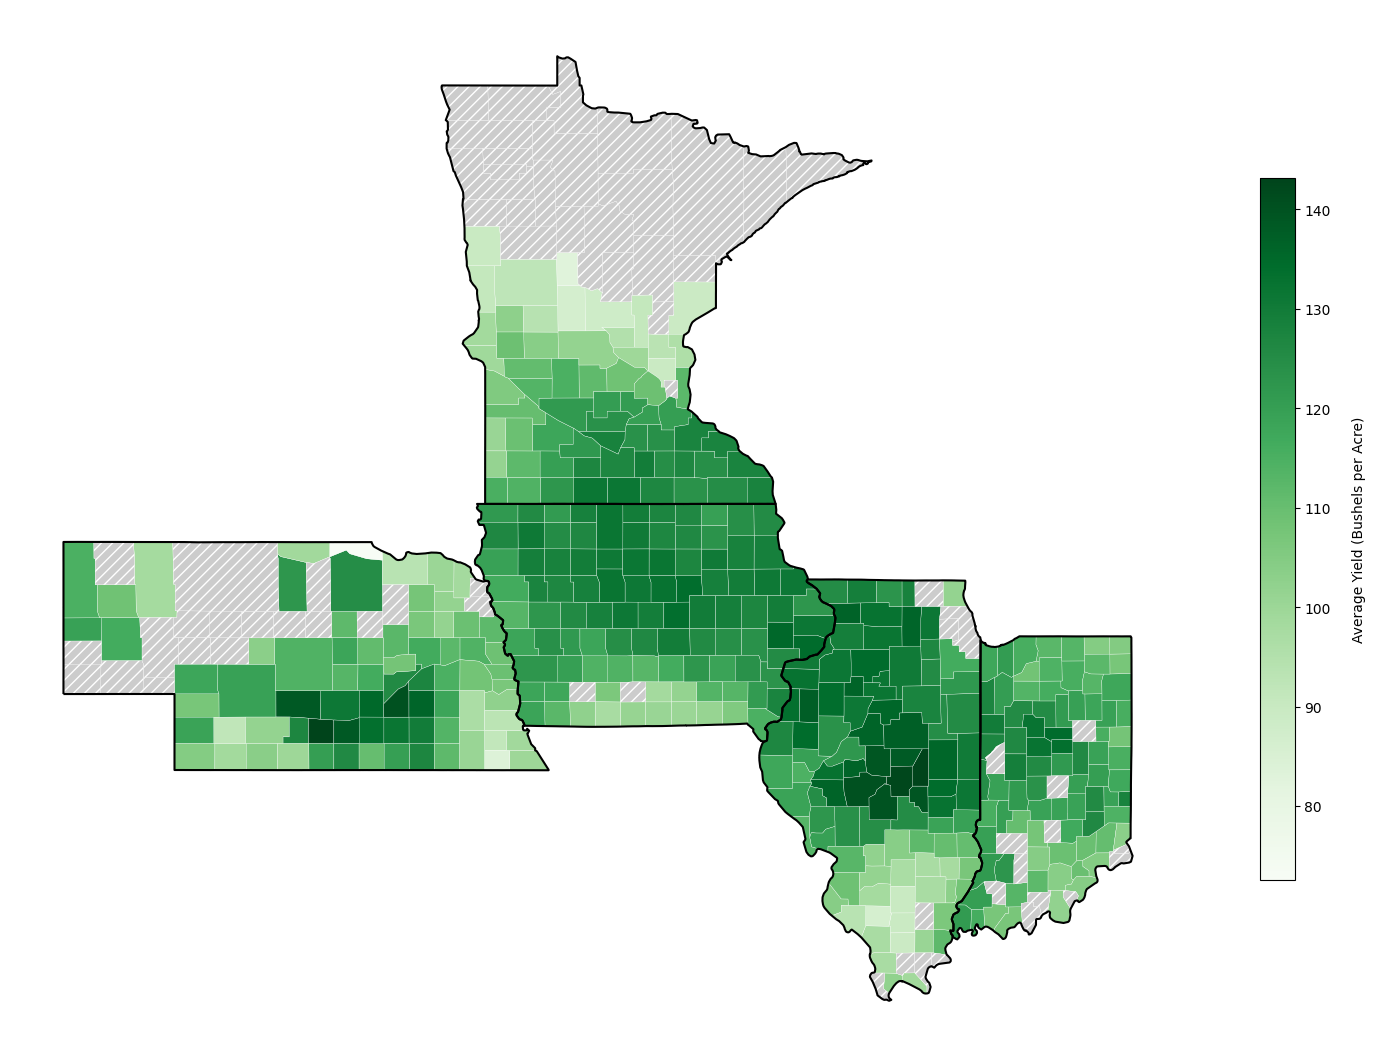

Map generation complete.


In [3]:
csv_file_to_process = '../master_panel_corn.csv' #df_dropped_detrended_Wrong
process_and_plot_yield_map(csv_file_to_process)

In [4]:
count_counties_per_state(csv_file_to_process)


--- County Counts per State (Found/Total) ---
17    94/102
18    80/92
19    97/99
27    63/87
31    74/93
------------------------------------------
Total    408/473


In [5]:
gs_stats = generate_descriptive_stats(csv_filepath=csv_file_to_process, season='GS')

Starting analysis for season: GS
Loading and preparing data from: df_dropped_master_dataDEMO_Wrong.csv
Calculating statistics...
Formatting the final table...

--- Descriptive Statistics (Raw and Anomaly) ---
Time Period: 1951-2024 | Season: GS | Baseline: 1981-2010
                         Count           Mean Climatological Mean        Std Dev       Skewness              Min             Max
Variable          State                                                                                                         
Yield (bu/acre)   IL      6834      119.4 (-)           132.7 (-)       48.2 (-)       0.28 (-)          9.0 (-)       248.2 (-)
                  IN      5825      116.3 (-)           130.1 (-)       42.9 (-)       0.24 (-)         22.2 (-)       234.4 (-)
                  IA      7104      122.0 (-)           136.2 (-)       47.7 (-)       0.17 (-)         18.3 (-)       240.9 (-)
                  MN      4600      111.0 (-)           127.2 (-)       48.9 (-)       0

Generating plot for variables: ['Yield'] for season: 'GS'
Loading and preparing data from: df_dropped_master_dataDEMO_Wrong.csv
Creating subplots grid...


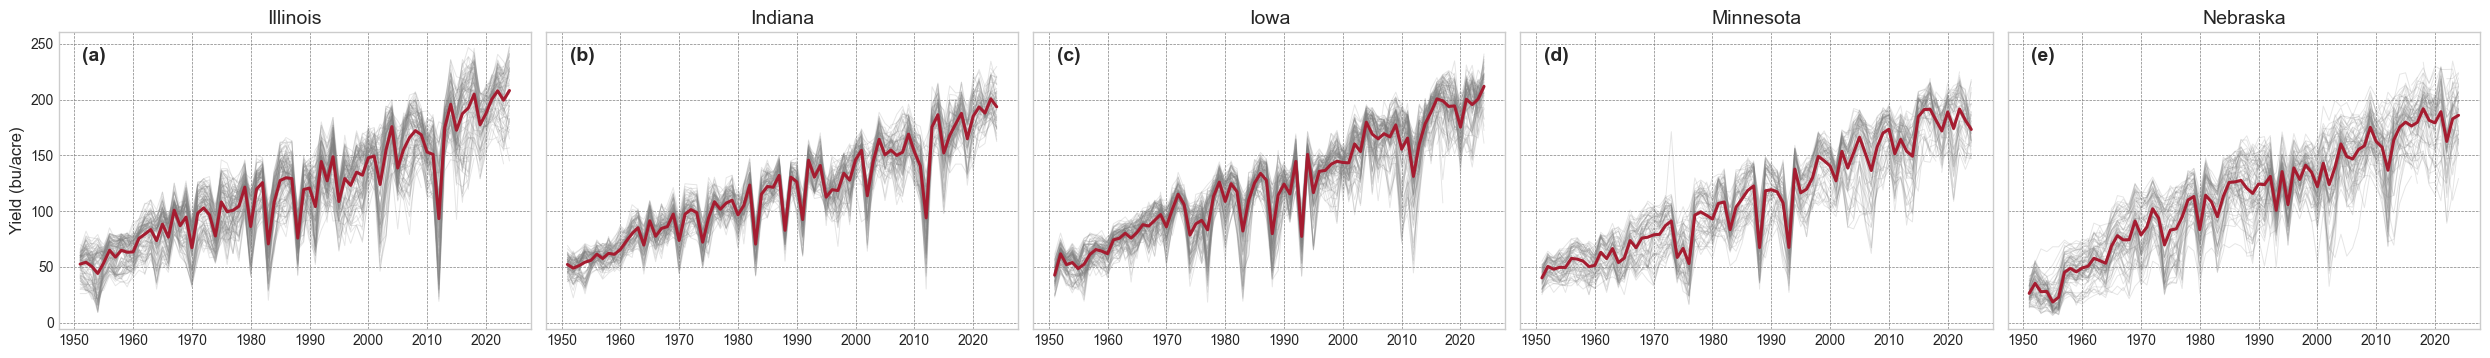

Plot generation complete.


In [6]:
# PLOT YIELD
# Example: Generate a 2x5 grid for 'Yield' and 'PREC'
plot_county_lines_by_state(
    csv_filepath=csv_file_to_process,
    variable_names=['Yield']
)

Generating dual-season plot for variables: ['TMAX_AVG', 'PREC']
Loading and preparing data...
Creating advanced plot grid...


C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:569: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax_gs.get_shared_y_axes().join(gs_row_master_ax[row_idx], ax_gs)
C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:570: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax_sgf.get_shared_y_axes().join(sgf_row_master_ax[row_idx], ax_sgf)
C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:618: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


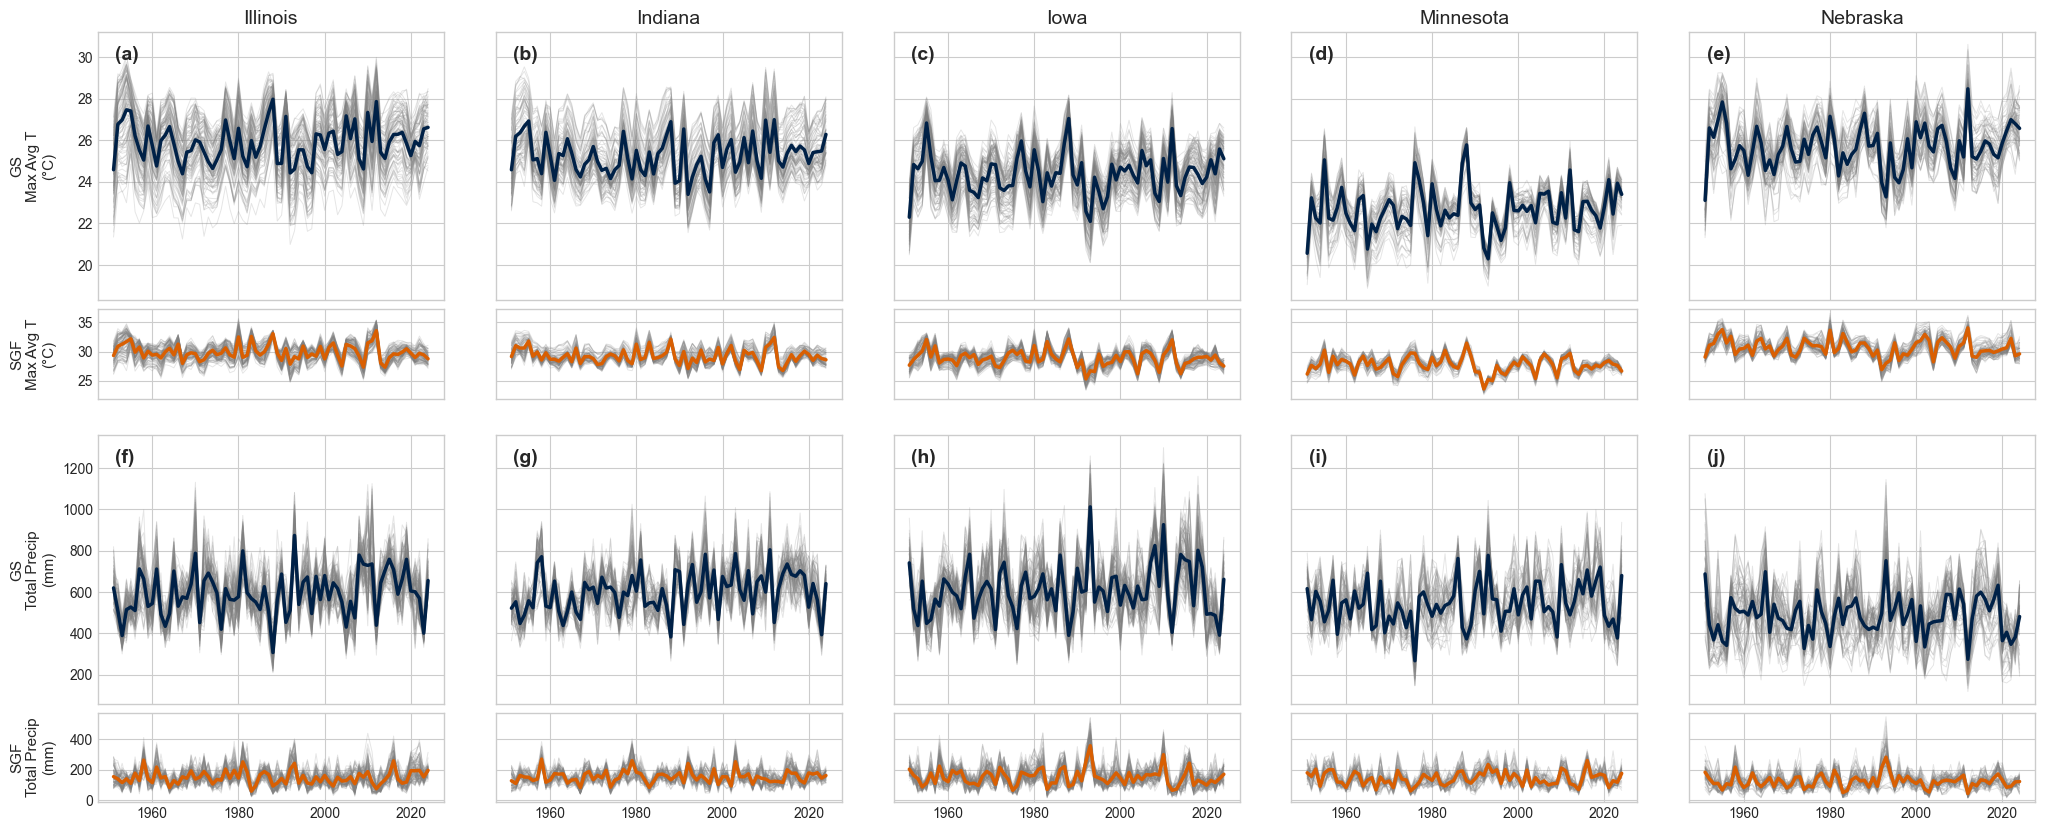

Plot generation complete.


In [7]:
import matplotlib.gridspec as gridspec
plot_dual_season_grid(
    csv_filepath=csv_file_to_process,
    variable_names=['TMAX_AVG', 'PREC']
)

Generating dual-season plot for variables: ['GDD', 'KDD']
Loading and preparing data...
Creating advanced plot grid...


C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:569: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax_gs.get_shared_y_axes().join(gs_row_master_ax[row_idx], ax_gs)
C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:570: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax_sgf.get_shared_y_axes().join(sgf_row_master_ax[row_idx], ax_sgf)
C:\Users\rickg\AppData\Local\Temp\ipykernel_13852\4205755869.py:618: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


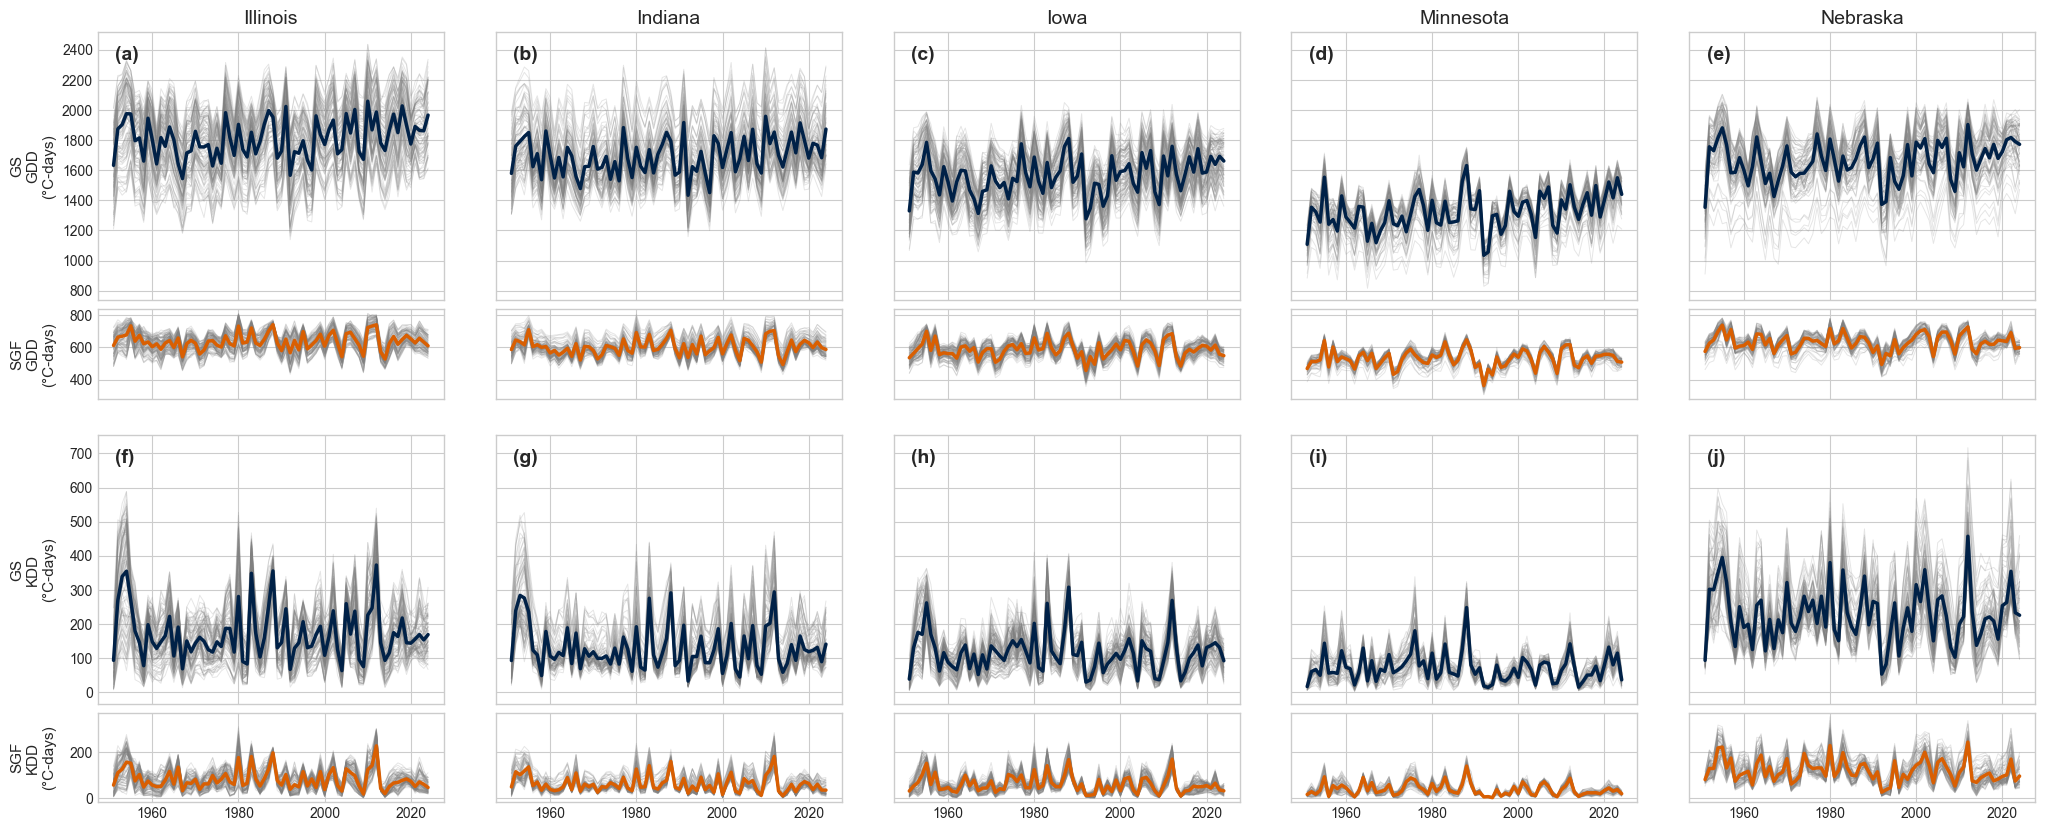

Plot generation complete.


In [8]:

# Example: Generate a plot for 'GDD' and 'PREC'
plot_dual_season_grid(
    csv_filepath=csv_file_to_process,
    variable_names=['GDD', 'KDD']
)



--- Generating: Model 2_3 with 'dtr' data ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


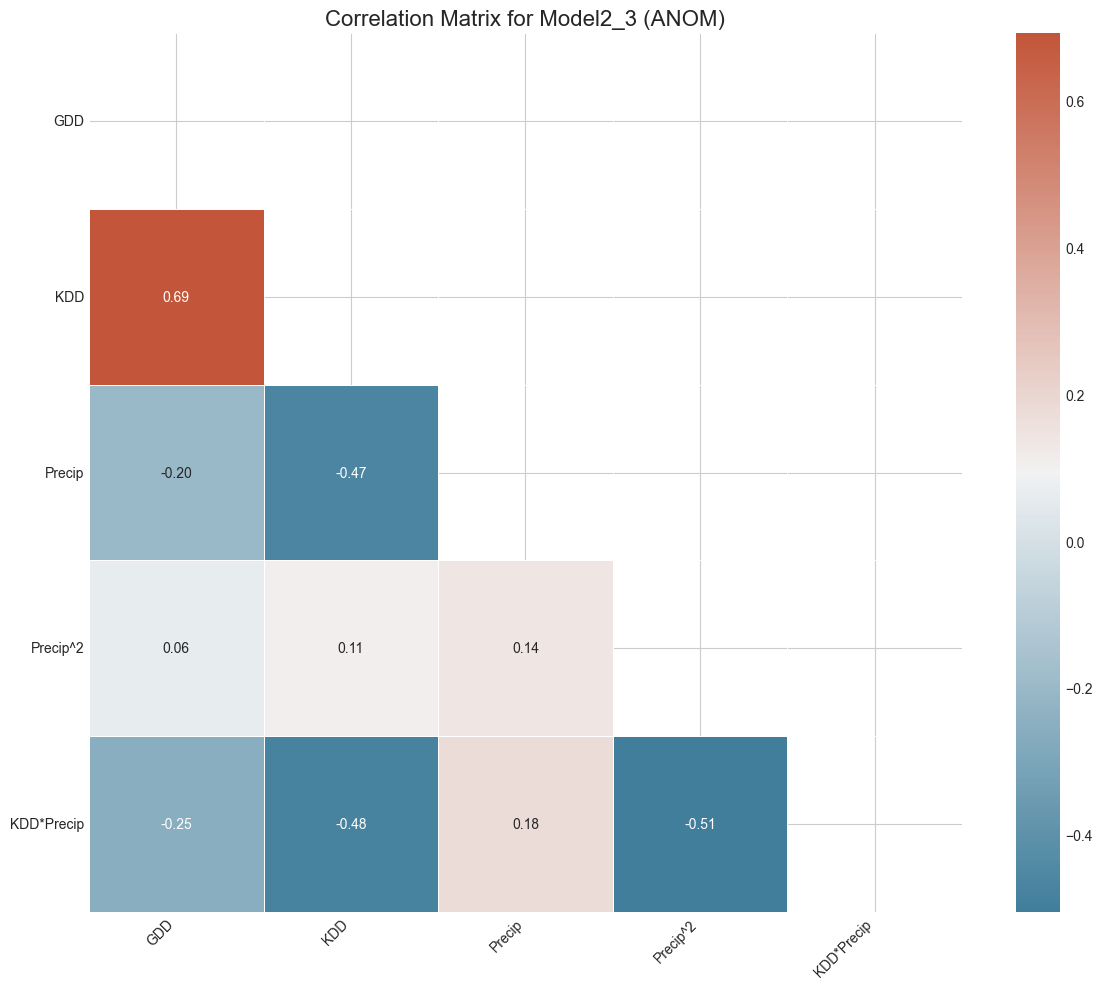


--- Generating: 'all' model with 'anom' data ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


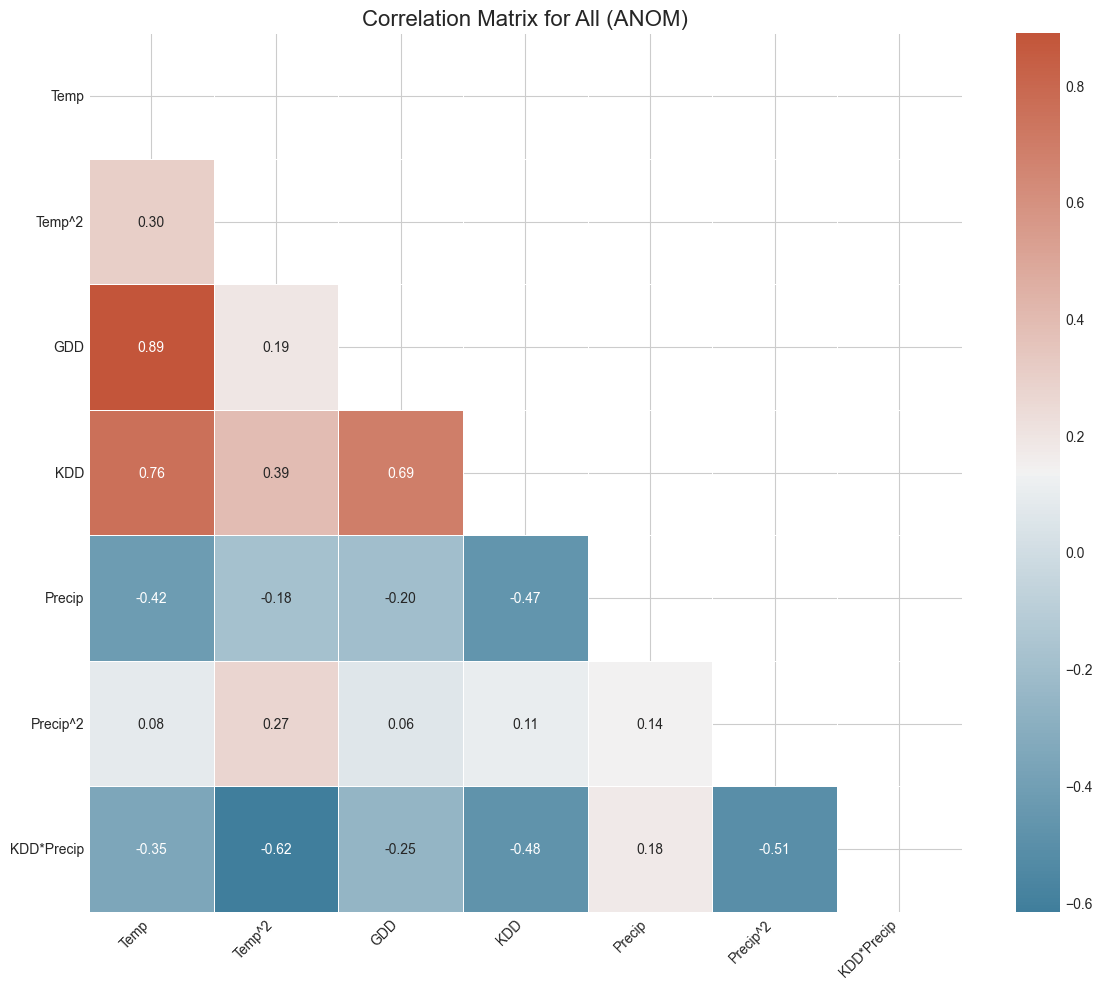


--- Generating: Model 1 with 'raw' data ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


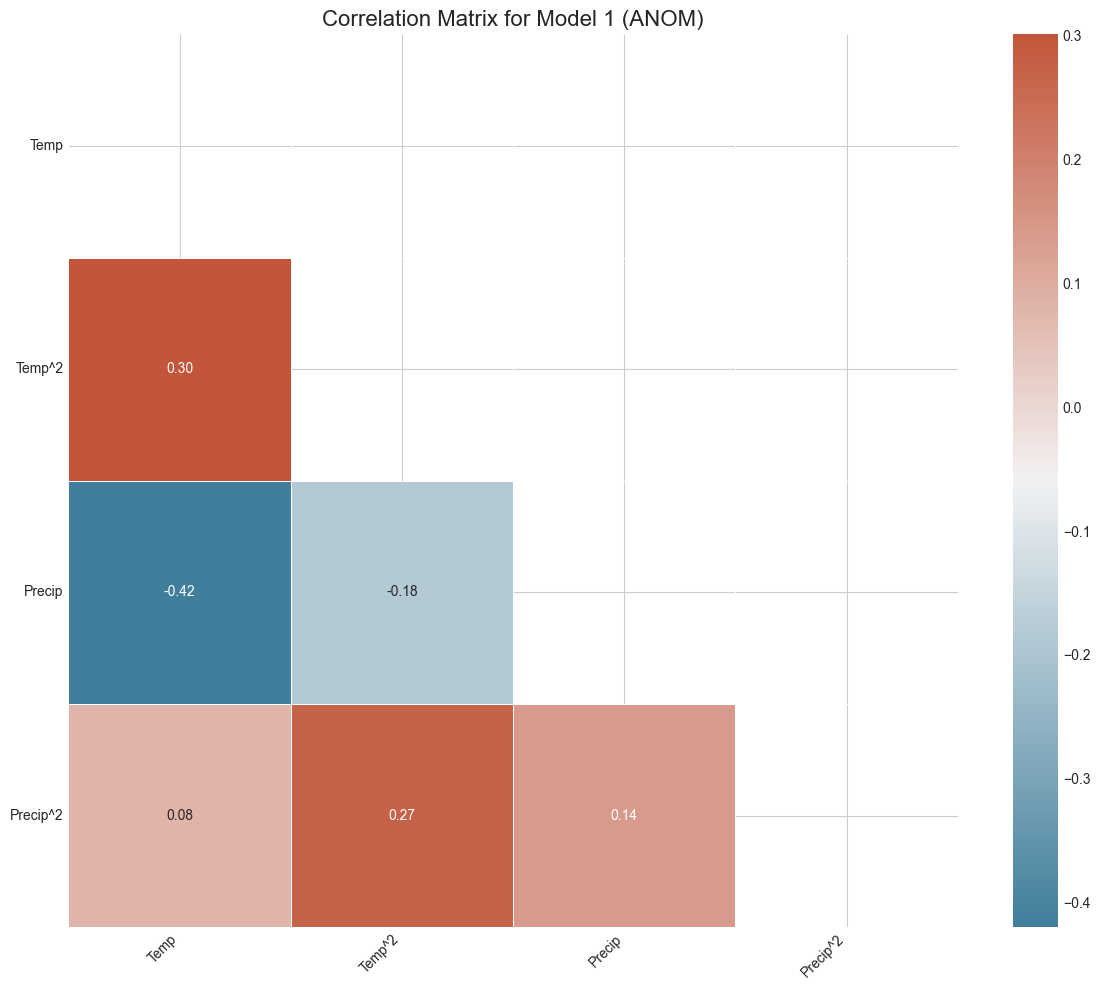

In [9]:


# --- Example Usage ---
file_to_use = '../master_panel_corn.csv'

print("\n--- Generating: Model 2_3 with 'dtr' data ---")
model2_3_dtr_corr = create_correlation_matrix(
    file_path=file_to_use,
    data_type='anom',
    model_name='model2_3',
    plot=True  # Generate plot for this model
)

print("\n--- Generating: 'all' model with 'anom' data ---")
all_anom_corr = create_correlation_matrix(
    file_path=file_to_use,
    data_type='anom',
    model_name='all',
    plot=True # Generate plot for this model
)

print("\n--- Generating: Model 1 with 'raw' data ---")
model_1_raw_corr = create_correlation_matrix(
    file_path=file_to_use,
    data_type='anom',
    model_name='model 1',
    plot=True # Generate plot for this model
)



--- Generating: Model 2_3 with 'anom' data for GS period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


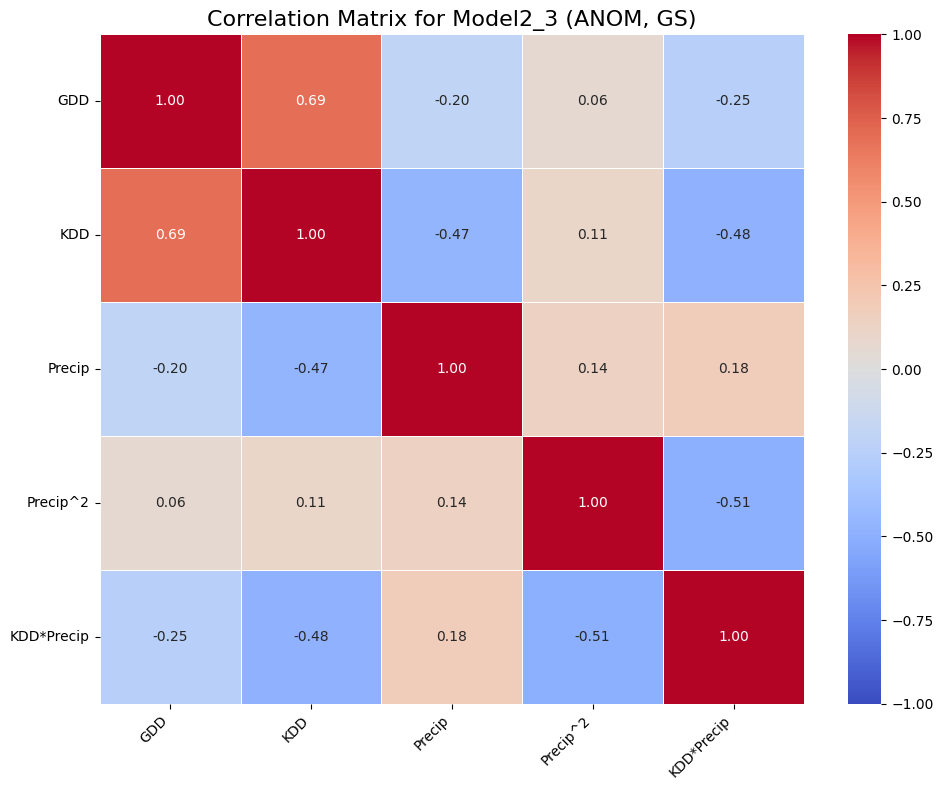


--- Generating: 'all' model with 'anom' data for SGF period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


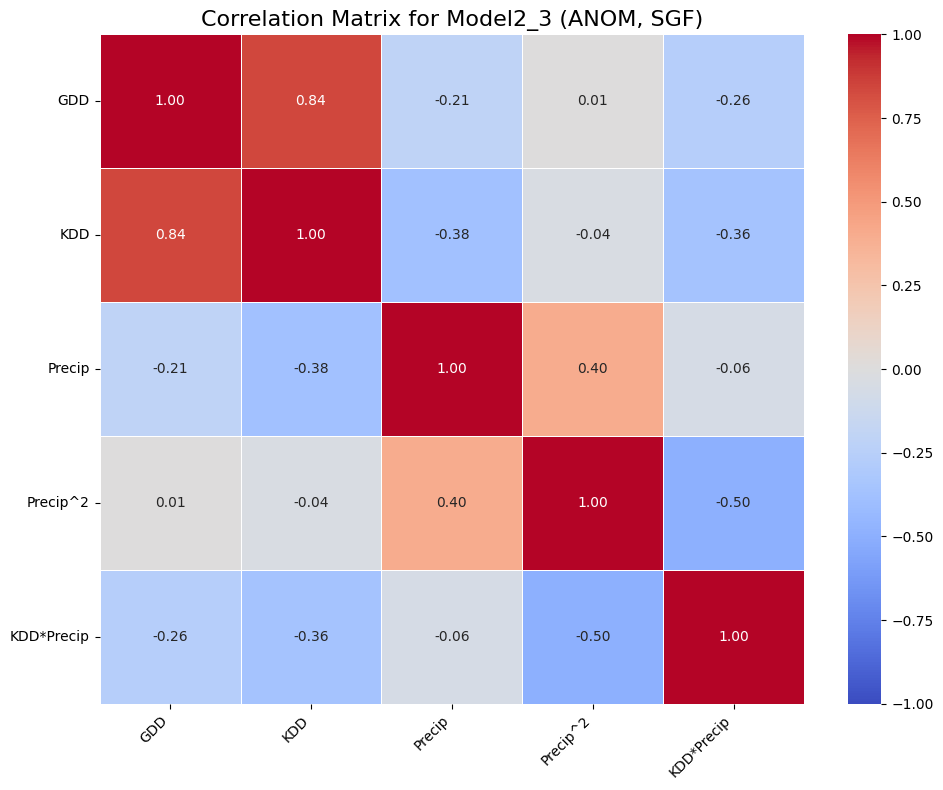


--- Generating: Model 1 with 'raw' data for GS period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


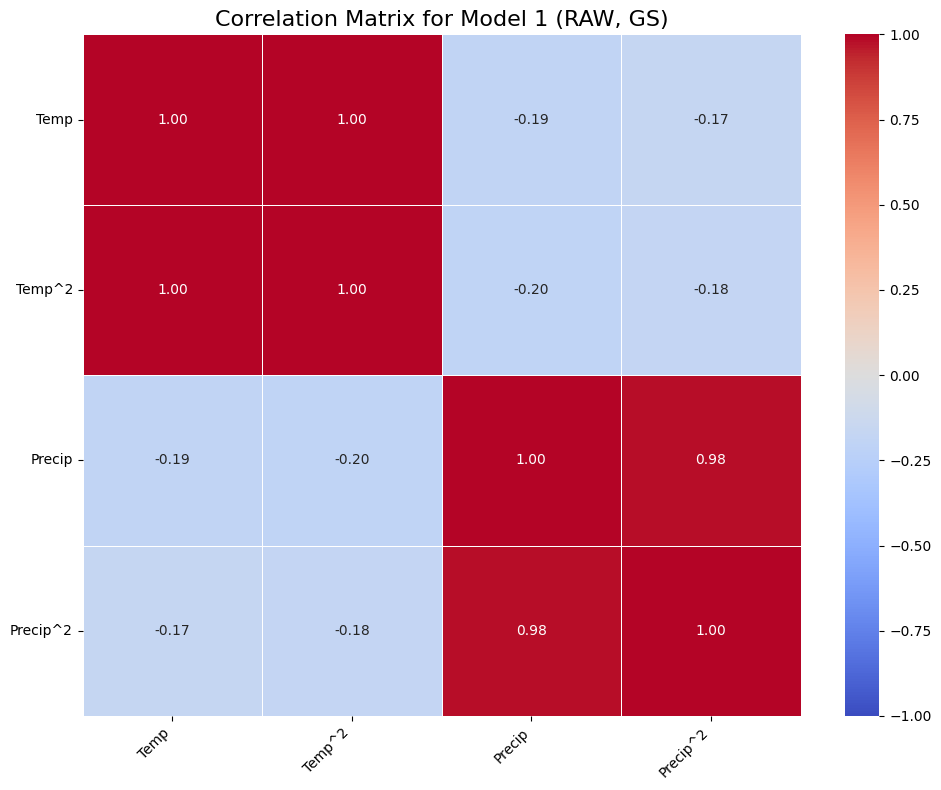

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(corr_matrix, title: str):
    """
    Helper function to plot a correlation matrix using seaborn.

    Args:
        corr_matrix (pd.DataFrame): The correlation matrix to plot.
        title (str): The title for the plot.
    """
    if corr_matrix.empty:
        print(f"Warning: Correlation matrix is empty. Skipping plot for '{title}'.")
        return
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def create_correlation_matrix(file_path: str, data_type: str, period: str, model_name: str, plot: bool = False) -> pd.DataFrame:
    """
    Generates and optionally plots a correlation matrix for specified model variables.

    Args:
        file_path (str): The path to the input CSV file.
        data_type (str): The type of data to use. Options: 'raw', 'dtr', 'anom'.
        period (str): The period to use for weather data. Options: 'GS', 'SGF'.
        model_name (str): The model for which to generate the correlation matrix.
                          Options: 'model 1', 'model2_3', 'all'.
        plot (bool): If True, a plot of the correlation matrix will be displayed.

    Returns:
        pd.DataFrame: A DataFrame containing the correlation matrix.
    """
    # --- 1. Input Validation ---
    if data_type not in ['raw', 'dtr', 'anom']:
        raise ValueError("Invalid data_type. Choose from 'raw', 'dtr', or 'anom'.")
    if period.upper() not in ['GS', 'SGF']:
        raise ValueError("Invalid period. Choose from 'GS' or 'SGF'.")
    if model_name not in ['model 1', 'model2_3', 'all']:
        raise ValueError("Invalid model_name. Choose from 'model 1', 'model2_3', or 'all'.")

    # --- 2. Load and Filter Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"Error: The file at {file_path} was not found.")

    df_filtered = df[df['year'] >= 1951].copy()
    print(f"Data loaded and filtered for years >= 1951. Shape: {df_filtered.shape}")

    # --- 3. Define Model Variables and Column Suffixes ---
    suffix_map = {'raw': '', 'dtr': '_dtr', 'anom': '_anom'}
    suffix = suffix_map[data_type]
    period_upper = period.upper()

    # --- 4. Define Base Column Names based on Period ---
    # This handles the different column naming conventions for GS and SGF periods.
    base_cols = {
        'GS': {'temp': 'temp_gs', 'precip': 'pcpn_gs', 'gdd': 'GDD_GS', 'kdd': 'KDD_GS'},
        'SGF': {'temp': 'TMAX_AVG_SGF', 'precip': 'PREC_SGF', 'gdd': 'GDD_SGF', 'kdd': 'KDD_SGF'}
    }
    period_base_cols = base_cols[period_upper]

    # --- 5. Create Squared Terms if Needed (for 'raw' data type) ---
    if data_type == 'raw':
        temp_base = period_base_cols['temp']
        precip_base = period_base_cols['precip']
        if f'{temp_base}_sq' not in df_filtered.columns:
            if temp_base in df_filtered.columns:
                df_filtered[f'{temp_base}_sq'] = df_filtered[temp_base] ** 2
        if f'{precip_base}_sq' not in df_filtered.columns:
            if precip_base in df_filtered.columns:
                df_filtered[f'{precip_base}_sq'] = df_filtered[precip_base] ** 2

    # --- 6. Map Generic Variable Names to Final Column Names ---
    variable_mapping = {
        'temp':      f"{period_base_cols['temp']}{suffix}",
        'temp_sq':   f"{period_base_cols['temp']}_sq{suffix}",
        'precip':    f"{period_base_cols['precip']}{suffix}",
        'precip_sq': f"{period_base_cols['precip']}_sq{suffix}",
        'gdd':       f"{period_base_cols['gdd']}{suffix}",
        'kdd':       f"{period_base_cols['kdd']}{suffix}",
    }
    # Override for anomaly squared columns which have a different naming convention
    if data_type == 'anom':
        variable_mapping['temp_sq'] = f"{period_base_cols['temp']}_anom_sq"
        variable_mapping['precip_sq'] = f"{period_base_cols['precip']}_anom_sq"

    # --- 7. Define Model Variables ---
    model_vars = {
        'model 1': ['temp', 'temp_sq', 'precip', 'precip_sq'],
        'model2_3': ['gdd', 'kdd', 'precip', 'precip_sq'],
        'all': ['temp', 'temp_sq', 'gdd', 'kdd', 'precip', 'precip_sq']
    }
    selected_vars = model_vars[model_name][:]  # Create a copy

    # --- 8. Create Interaction Terms ---
    if model_name in ['model2_3', 'all']:
        kdd_col = variable_mapping['kdd']
        precip_col = variable_mapping['precip']
        
        # Define a dynamic name for the interaction term column
        kdd_precip_col_name = f'kdd_x_precip_{period.lower()}{suffix}'
        
        # Check if base columns exist before creating the interaction term
        if kdd_col in df_filtered.columns and precip_col in df_filtered.columns:
            df_filtered[kdd_precip_col_name] = df_filtered[kdd_col] * df_filtered[precip_col]
            variable_mapping['kdd_precip'] = kdd_precip_col_name
            selected_vars.extend(['kdd_precip'])
        else:
            print(f"Warning: Could not create interaction term. Missing one or both columns: '{kdd_col}', '{precip_col}'")

    # --- 9. Select Columns and Compute Correlation Matrix ---
    final_columns = [variable_mapping[var] for var in selected_vars if var in variable_mapping]
    
    existing_final_columns = [col for col in final_columns if col in df_filtered.columns]
    missing_cols = [col for col in final_columns if col not in df_filtered.columns]
    
    if missing_cols:
        print(f"Warning: Missing required columns for data_type '{data_type}' and period '{period_upper}': {missing_cols}")
        print(f"Correlation matrix will be generated with available columns: {existing_final_columns}")

    if not existing_final_columns:
        print("Error: No columns available to generate a correlation matrix. Returning empty DataFrame.")
        return pd.DataFrame()

    correlation_matrix = df_filtered[existing_final_columns].corr()

    # --- 10. Plotting ---
    if plot:
        label_mapping = {
            'temp': 'Temp', 'temp_sq': 'Temp^2',
            'precip': 'Precip', 'precip_sq': 'Precip^2',
            'gdd': 'GDD', 'kdd': 'KDD', 'kdd_precip': 'KDD*Precip'
        }
        
        reverse_variable_mapping = {v: k for k, v in variable_mapping.items()}
        plot_labels = [label_mapping.get(reverse_variable_mapping.get(col)) for col in correlation_matrix.columns]

        plot_corr_matrix = correlation_matrix.copy()
        plot_corr_matrix.columns = plot_labels
        plot_corr_matrix.index = plot_labels

        plot_title = f"Correlation Matrix for {model_name.title()} ({data_type.upper()}, {period_upper})"
        plot_correlation_matrix(plot_corr_matrix, title=plot_title)

    return correlation_matrix


# --- Example Usage ---
# Note: Ensure the specified CSV file is in the same directory or provide a full path.
try:
    file_to_use = '../master_panel_corn.csv'

    print("\n--- Generating: Model 2_3 with 'anom' data for GS period ---")
    model2_3_anom_gs_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='anom',
        period='GS',
        model_name='model2_3',
        plot=True
    )

    print("\n--- Generating: 'all' model with 'anom' data for SGF period ---")
    # Note: 'model all' for SGF uses TMAX_AVG_SGF and PREC_SGF for temp/precip variables.
    all_anom_sgf_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='anom',
        period='SGF',
        model_name='model2_3',
        plot=True
    )

    print("\n--- Generating: Model 1 with 'raw' data for GS period ---")
    model_1_raw_gs_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='raw',
        period='GS',
        model_name='model 1',
        plot=True
    )

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An unexpected error occurred: {e}")


--- Generating: Model 2_3 with 'anom' data for GS period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


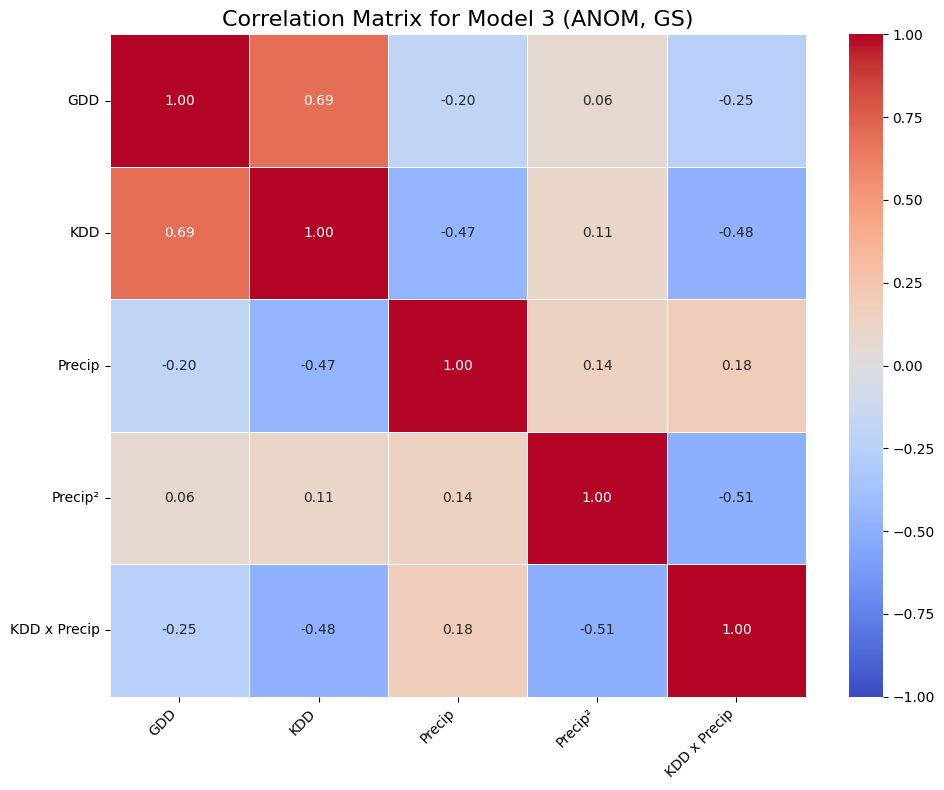


--- Generating: 'all' model with 'anom' data for SGF period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


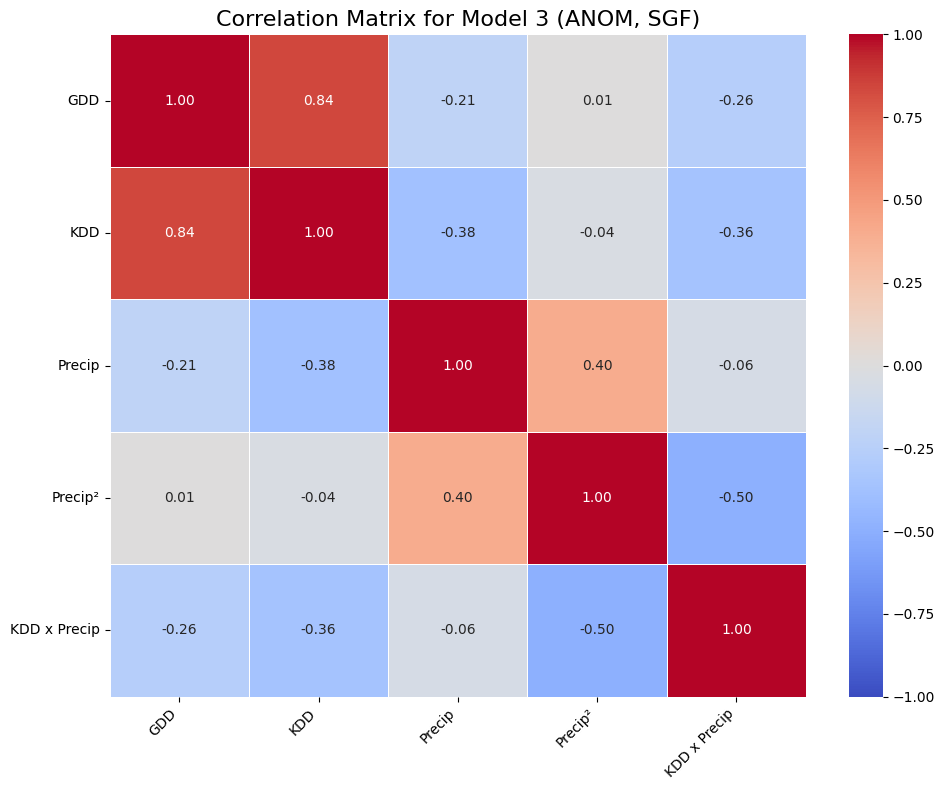


--- Generating: Model 1 with 'raw' data for GS period ---
Data loaded and filtered for years >= 1951. Shape: (30192, 177)


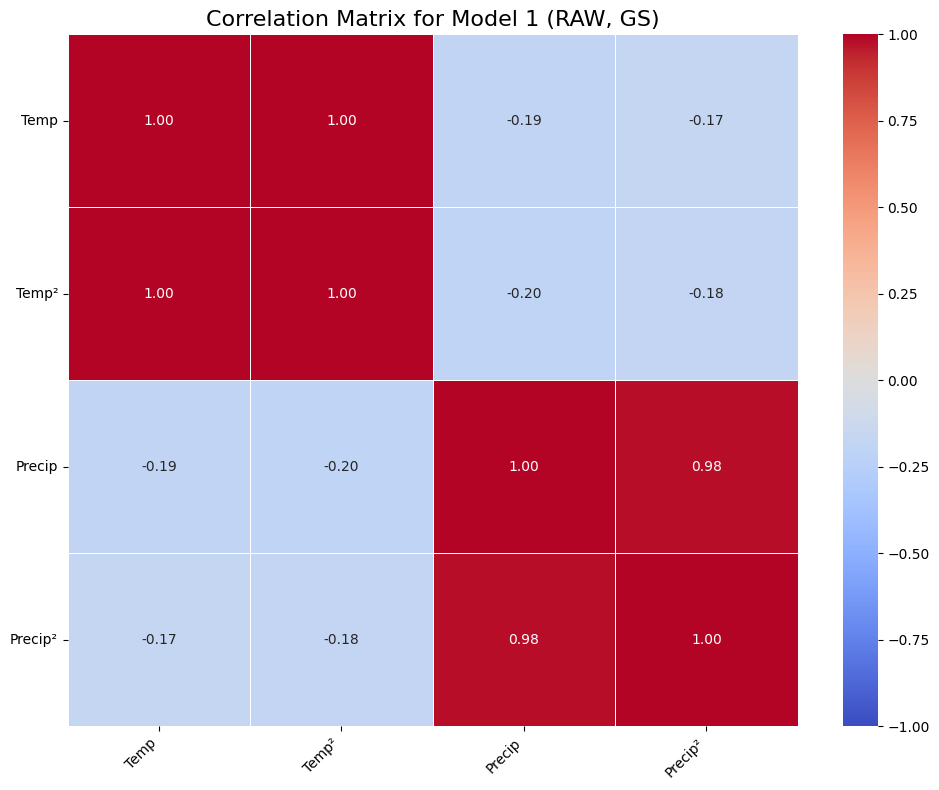

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(corr_matrix, title: str):
    """
    Helper function to plot a correlation matrix using seaborn.

    Args:
        corr_matrix (pd.DataFrame): The correlation matrix to plot.
        title (str): The title for the plot.
    """
    if corr_matrix.empty:
        print(f"Warning: Correlation matrix is empty. Skipping plot for '{title}'.")
        return
    plt.figure(figsize=(10, 8))
    # Changed cmap back to 'coolwarm' as requested.
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def create_correlation_matrix(file_path: str, data_type: str, period: str, model_name: str, plot: bool = False) -> pd.DataFrame:
    """
    Generates and optionally plots a correlation matrix for specified model variables.

    Args:
        file_path (str): The path to the input CSV file.
        data_type (str): The type of data to use. Options: 'raw', 'dtr', 'anom'.
        period (str): The period to use for weather data. Options: 'GS', 'SGF'.
        model_name (str): The model for which to generate the correlation matrix.
                          Options: 'model 1', 'model2_3', 'all'.
        plot (bool): If True, a plot of the correlation matrix will be displayed.

    Returns:
        pd.DataFrame: A DataFrame containing the correlation matrix.
    """
    # --- 1. Input Validation ---
    if data_type not in ['raw', 'dtr', 'anom']:
        raise ValueError("Invalid data_type. Choose from 'raw', 'dtr', or 'anom'.")
    if period.upper() not in ['GS', 'SGF']:
        raise ValueError("Invalid period. Choose from 'GS' or 'SGF'.")
    if model_name not in ['model 1', 'model2_3', 'all']:
        raise ValueError("Invalid model_name. Choose from 'model 1', 'model2_3', or 'all'.")

    # --- 2. Load and Filter Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"Error: The file at {file_path} was not found.")

    df_filtered = df[df['year'] >= 1951].copy()
    print(f"Data loaded and filtered for years >= 1951. Shape: {df_filtered.shape}")

    # --- 3. Define Model Variables and Column Suffixes ---
    suffix_map = {'raw': '', 'dtr': '_dtr', 'anom': '_anom'}
    suffix = suffix_map[data_type]
    period_upper = period.upper()

    # --- 4. Define Base Column Names based on Period ---
    # This handles the different column naming conventions for GS and SGF periods.
    base_cols = {
        'GS': {'temp': 'temp_gs', 'precip': 'pcpn_gs', 'gdd': 'GDD_GS', 'kdd': 'KDD_GS'},
        'SGF': {'temp': 'TMAX_AVG_SGF', 'precip': 'PREC_SGF', 'gdd': 'GDD_SGF', 'kdd': 'KDD_SGF'}
    }
    period_base_cols = base_cols[period_upper]

    # --- 5. Create Squared Terms if Needed (for 'raw' data type) ---
    if data_type == 'raw':
        temp_base = period_base_cols['temp']
        precip_base = period_base_cols['precip']
        if f'{temp_base}_sq' not in df_filtered.columns:
            if temp_base in df_filtered.columns:
                df_filtered[f'{temp_base}_sq'] = df_filtered[temp_base] ** 2
        if f'{precip_base}_sq' not in df_filtered.columns:
            if precip_base in df_filtered.columns:
                df_filtered[f'{precip_base}_sq'] = df_filtered[precip_base] ** 2

    # --- 6. Map Generic Variable Names to Final Column Names ---
    variable_mapping = {
        'temp':      f"{period_base_cols['temp']}{suffix}",
        'temp_sq':   f"{period_base_cols['temp']}_sq{suffix}",
        'precip':    f"{period_base_cols['precip']}{suffix}",
        'precip_sq': f"{period_base_cols['precip']}_sq{suffix}",
        'gdd':       f"{period_base_cols['gdd']}{suffix}",
        'kdd':       f"{period_base_cols['kdd']}{suffix}",
    }
    # Override for anomaly squared columns which have a different naming convention
    if data_type == 'anom':
        variable_mapping['temp_sq'] = f"{period_base_cols['temp']}_anom_sq"
        variable_mapping['precip_sq'] = f"{period_base_cols['precip']}_anom_sq"

    # --- 7. Define Model Variables ---
    model_vars = {
        'model 1': ['temp', 'temp_sq', 'precip', 'precip_sq'],
        'model2_3': ['gdd', 'kdd', 'precip', 'precip_sq'],
        'all': ['temp', 'temp_sq', 'gdd', 'kdd', 'precip', 'precip_sq']
    }
    selected_vars = model_vars[model_name][:]  # Create a copy

    # --- 8. Create Interaction Terms ---
    if model_name in ['model2_3', 'all']:
        kdd_col = variable_mapping['kdd']
        precip_col = variable_mapping['precip']
        
        # Define a dynamic name for the interaction term column
        kdd_precip_col_name = f'kdd_x_precip_{period.lower()}{suffix}'
        
        # Check if base columns exist before creating the interaction term
        if kdd_col in df_filtered.columns and precip_col in df_filtered.columns:
            df_filtered[kdd_precip_col_name] = df_filtered[kdd_col] * df_filtered[precip_col]
            variable_mapping['kdd_precip'] = kdd_precip_col_name
            selected_vars.extend(['kdd_precip'])
        else:
            print(f"Warning: Could not create interaction term. Missing one or both columns: '{kdd_col}', '{precip_col}'")

    # --- 9. Select Columns and Compute Correlation Matrix ---
    final_columns = [variable_mapping[var] for var in selected_vars if var in variable_mapping]
    
    existing_final_columns = [col for col in final_columns if col in df_filtered.columns]
    missing_cols = [col for col in final_columns if col not in df_filtered.columns]
    
    if missing_cols:
        print(f"Warning: Missing required columns for data_type '{data_type}' and period '{period_upper}': {missing_cols}")
        print(f"Correlation matrix will be generated with available columns: {existing_final_columns}")

    if not existing_final_columns:
        print("Error: No columns available to generate a correlation matrix. Returning empty DataFrame.")
        return pd.DataFrame()

    correlation_matrix = df_filtered[existing_final_columns].corr()

    # --- 10. Plotting ---
    if plot:
        label_mapping = {
            'temp': 'Temp', 'temp_sq': 'Temp²',
            'precip': 'Precip', 'precip_sq': 'Precip²',
            'gdd': 'GDD', 'kdd': 'KDD', 'kdd_precip': 'KDD x Precip'
        }
        
        reverse_variable_mapping = {v: k for k, v in variable_mapping.items()}
        plot_labels = [label_mapping.get(reverse_variable_mapping.get(col)) for col in correlation_matrix.columns]

        plot_corr_matrix = correlation_matrix.copy()
        plot_corr_matrix.columns = plot_labels
        plot_corr_matrix.index = plot_labels

        # Custom title logic
        if model_name == 'model2_3':
            plot_title = f"Correlation Matrix for Model 3 ({data_type.upper()}, {period_upper})"
        else:
            plot_title = f"Correlation Matrix for {model_name.title()} ({data_type.upper()}, {period_upper})"
        
        plot_correlation_matrix(plot_corr_matrix, title=plot_title)

    return correlation_matrix


# --- Example Usage ---
# Note: Ensure the specified CSV file is in the same directory or provide a full path.
try:
    file_to_use = '../master_panel_corn.csv'

    print("\n--- Generating: Model 2_3 with 'anom' data for GS period ---")
    model2_3_anom_gs_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='anom',
        period='GS',
        model_name='model2_3',
        plot=True
    )

    print("\n--- Generating: 'all' model with 'anom' data for SGF period ---")
    # Note: 'model all' for SGF uses TMAX_AVG_SGF and PREC_SGF for temp/precip variables.
    all_anom_sgf_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='anom',
        period='SGF',
        model_name='model2_3',
        plot=True
    )

    print("\n--- Generating: Model 1 with 'raw' data for GS period ---")
    model_1_raw_gs_corr = create_correlation_matrix(
        file_path=file_to_use,
        data_type='raw',
        period='GS',
        model_name='model 1',
        plot=True
    )

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An unexpected error occurred: {e}")